In [12]:
#Импорт необходимых библеотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [4]:
#Загружаем нужные CSV-файлы
df = pd.read_csv('/Users/valentinayerokhina/Desktop/MyPythonProjects/Capstone/Data/Cleaned/for_ml.csv')


In [3]:
#Проверка
print(df.shape)
print(df.columns.tolist())

(42085, 11)
['Дата', 'Номер_чека', 'Категория', 'Сумма_без_скидки', 'Сумма_со_скидкой', 'customer_id', 'Возраст', 'Год', 'Месяц', 'Сумма_чистая', 'Дата_только']


In [5]:
#Создаем характеристики 
features = df.groupby('customer_id').agg(
    total_spent=('Сумма_чистая', 'sum'),
    average_check=('Сумма_чистая', 'mean'),
    number_of_visits=('Номер_чека', 'nunique'),
    first_purchase=('Дата_только', 'min'),
    last_purchase=('Дата_только', 'max'),
    age=('Возраст', 'first'),
    favorite_category=('Категория', lambda x: x.value_counts().index[0]),
    first_purchase_type=('Категория', 'first')
).reset_index()

print(features.shape)
print(features.head())

(29538, 9)
                        customer_id  total_spent  average_check  \
0  00008f456af0350d1bc645da8f8a4c25       3000.0         3000.0   
1  00067877bd7ebf0c1fd6efa81aca1de0       2000.0         2000.0   
2  0007340ae2b5bb4fdfbb26de15e148f5      33267.0        33267.0   
3  000db87d70b05184f7be5578709b07a2      22907.0        11453.5   
4  000fb62cd4bade868a372390d03a1cfe      19410.0        19410.0   

   number_of_visits first_purchase last_purchase   age favorite_category  \
0                 1     2022-10-14    2022-10-14  64.0   Проверка зрения   
1                 1     2022-08-18    2022-08-18  39.0   Проверка зрения   
2                 1     2022-12-28    2022-12-28  52.0   Изготовл. очков   
3                 2     2023-04-11    2023-04-11  53.0   Проверка зрения   
4                 1     2024-03-24    2024-03-24  62.0   Изготовл. очков   

  first_purchase_type  
0     Проверка зрения  
1     Проверка зрения  
2     Изготовл. очков  
3     Проверка зрения  
4     Изг

In [7]:
# Вытаскиваем данные первого визита из исходных транзакций
df['Дата_только'] = pd.to_datetime(df['Дата_только'])

first_visit = df.sort_values('Дата_только').groupby('customer_id').first().reset_index()
first_visit = first_visit[['customer_id', 'Сумма_чистая', 'Категория']].rename(columns={
    'Сумма_чистая': 'first_visit_amount',
    'Категория': 'first_visit_category'
})

# Добавляем количество визитов из features
first_visit = first_visit.merge(
    features[['customer_id', 'number_of_visits']],
    on='customer_id'
)

# Таргет — вернулся или нет
first_visit['target'] = (first_visit['number_of_visits'] > 1).astype(int)

print(first_visit.shape)
print(first_visit['target'].value_counts())
print(first_visit.head())

(29538, 5)
target
0    19730
1     9808
Name: count, dtype: int64
                        customer_id  first_visit_amount first_visit_category  \
0  00008f456af0350d1bc645da8f8a4c25              3000.0      Проверка зрения   
1  00067877bd7ebf0c1fd6efa81aca1de0              2000.0      Проверка зрения   
2  0007340ae2b5bb4fdfbb26de15e148f5             33267.0      Изготовл. очков   
3  000db87d70b05184f7be5578709b07a2              1950.0      Проверка зрения   
4  000fb62cd4bade868a372390d03a1cfe             19410.0      Изготовл. очков   

   number_of_visits  target  
0                 1       0  
1                 1       0  
2                 1       0  
3                 2       1  
4                 1       0  


In [8]:
# Собираем ml_df — только признаки первого визита
ml_df = first_visit[['first_visit_amount', 'first_visit_category', 'target']].copy()

# Кодируем категориальный признак
ml_df = pd.get_dummies(ml_df, columns=['first_visit_category'])

# Убираем NaN
ml_df = ml_df.dropna()

print(ml_df.shape)
print(ml_df.columns.tolist())

(29538, 7)
['first_visit_amount', 'target', 'first_visit_category_Изготовл. очков', 'first_visit_category_Контакт. линзы', 'first_visit_category_Проверка зрения', 'first_visit_category_Продажа', 'first_visit_category_Ремонт']


In [9]:
X = ml_df.drop(columns=['target'])
y = ml_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Баланс классов в train: {y_train.value_counts().to_dict()}")

Train: (23630, 6), Test: (5908, 6)
Баланс классов в train: {0: 15784, 1: 7846}


## Логистическая регрессия

Базовая модель бинарной классификации. Параметр `class_weight='balanced'` 
компенсирует дисбаланс классов (67% не вернулись / 33% вернулись).

In [32]:
X_train_cat = X_train.drop(columns=['first_visit_amount'])
X_test_cat = X_test.drop(columns=['first_visit_amount'])

scaler_cat = StandardScaler()
X_train_cat_scaled = scaler_cat.fit_transform(X_train_cat)
X_test_cat_scaled = scaler_cat.transform(X_test_cat)

lr_cat = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_cat.fit(X_train_cat_scaled, y_train)
y_pred_lr_cat = lr_cat.predict(X_test_cat_scaled)


cm = confusion_matrix(y_test, y_pred_lr_cat)

cm_df = pd.DataFrame({
    'Actual': ['did not return', 'did not return', 'returned', 'returned'],
    'Predicted': ['did not return', 'returned', 'did not return', 'returned'],
    'Count': [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
})

cm_df.to_csv('confusion_matrix.csv', index=False)
cm_df
print(classification_report(y_test, y_pred_lr_cat))

              precision    recall  f1-score   support

           0       0.71      0.60      0.65      3946
           1       0.38      0.50      0.43      1962

    accuracy                           0.57      5908
   macro avg       0.54      0.55      0.54      5908
weighted avg       0.60      0.57      0.58      5908



In [ ]:
X = ml_df.drop(columns=['target'])
y = ml_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

# Логрегрессия
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

(23630, 6) (5908, 6)
Logistic Regression:
              precision    recall  f1-score   support

           0       0.71      0.60      0.65      3946
           1       0.38      0.50      0.43      1962

    accuracy                           0.57      5908
   macro avg       0.54      0.55      0.54      5908
weighted avg       0.60      0.57      0.58      5908

Random Forest:
              precision    recall  f1-score   support

           0       0.80      0.64      0.71      3946
           1       0.48      0.68      0.57      1962

    accuracy                           0.65      5908
   macro avg       0.64      0.66      0.64      5908
weighted avg       0.70      0.65      0.66      5908



## Случайный лес (Random Forest)

Ансамблевая модель из 100 деревьев решений. Голосование большинства 
деревьев даёт более устойчивый результат чем одна модель.
Параметр `class_weight='balanced'` компенсирует дисбаланс классов.

In [28]:
X_train_cat = X_train.drop(columns=['first_visit_amount'])
X_test_cat = X_test.drop(columns=['first_visit_amount'])

rf_cat = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
rf_cat.fit(X_train_cat, y_train)
y_pred_cat = rf_cat.predict(X_test_cat)

print(classification_report(y_test, y_pred_cat))

              precision    recall  f1-score   support

           0       0.71      0.60      0.65      3946
           1       0.38      0.50      0.43      1962

    accuracy                           0.57      5908
   macro avg       0.54      0.55      0.54      5908
weighted avg       0.60      0.57      0.58      5908



## Важность признаков — Random Forest

Показывает вклад каждого признака в предсказание модели. 
## Важность категории первого визита

Убираем сумму чека — смотрим только на категорию первого визита.
Это покажет какой тип услуги влияет на возврат пациента.

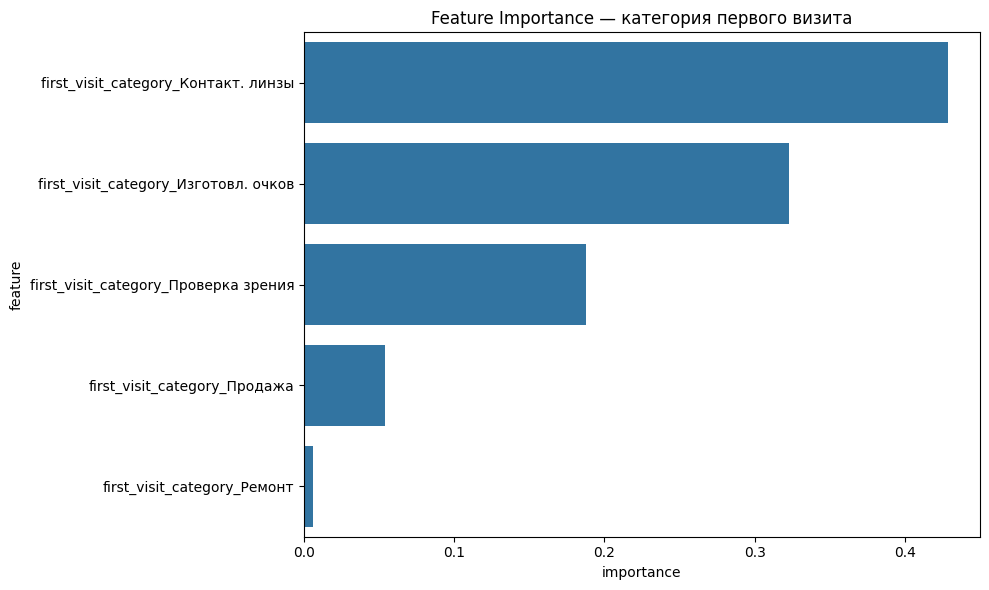

In [29]:
importance_df = pd.DataFrame({
    'feature': X_train_cat.columns,
    'importance': rf_cat.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature Importance — категория первого визита')
plt.tight_layout()
plt.show()

## Сравнение моделей

### С суммой первого визита
| Модель | Accuracy | Recall (вернулся) | F1 (вернулся) |
|---|---|---|---|
| Logistic Regression | 0.57 | 0.50 | 0.43 |
| Random Forest | 0.65 | 0.68 | 0.57 |

### Только категория первого визита
| Модель | Accuracy | Recall (вернулся) | F1 (вернулся) |
|---|---|---|---|
| Logistic Regression | 0.57 | 0.50 | 0.43 |
| Random Forest | 0.57 | 0.50 | 0.43 |

**Вывод:** без суммы чека обе модели одинаково слабые.
Категория первого визита важна для понимания бизнес-инсайтов,
но недостаточна для точного предсказания возврата.

## Вывод

После устранения data leakage модель обучается только на признаках 
первого визита: сумма чека и категория услуги.

**Feature Importance показал:**
- Контактные линзы — strongest predictor (0.44)
- Изготовление очков — второй по силе (0.33)
- Проверка зрения — средний предиктор (0.19)
- Продажа и ремонт — слабые предикторы

**Бизнес-вывод:** клиенты пришедшие за линзами и очками 
возвращаются чаще — это подтверждается природой продукта 
(линзы требуют регулярной замены, очки — сервиса).

**Feature poverty:** только два признака первого визита 
ограничивают предсказательную силу модели. Accuracy 65% — 
честный результат реальных данных.

In [33]:
## Экспорт метрик для Power BI
# Метрики моделей
metrics_df = pd.DataFrame({
    'model': ['Logistic Regression', 'Random Forest (with first_visit_amount)', 'Random Forest (only_category)'],
    'accuracy': [0.57, 0.65, 0.57],
    'recall_class1': [0.50, 0.68, 0.50],
    'f1_class1': [0.43, 0.57, 0.43]
})
metrics_df.to_csv('../data/model_metrics.csv', index=False)


# Feature importance
importance_df = pd.DataFrame({
    'feature': X_train_cat.columns,
    'importance': rf_cat.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.to_csv('../data/feature_importance.csv', index=False)

print("Готово!")
print(metrics_df)
print(importance_df)

Готово!
                                     model  accuracy  recall_class1  f1_class1
0                      Logistic Regression      0.57           0.50       0.43
1  Random Forest (with first_visit_amount)      0.65           0.68       0.57
2            Random Forest (only_category)      0.57           0.50       0.43
                                feature  importance
1   first_visit_category_Контакт. линзы    0.428615
0  first_visit_category_Изготовл. очков    0.323123
2  first_visit_category_Проверка зрения    0.188063
3          first_visit_category_Продажа    0.054292
4           first_visit_category_Ремонт    0.005907
